# Datawell Consultancy
## Project: Healthcare Claims Analytics
### Phase 2 — KPI Analysis & Business Insights
---
**Prepared by:** Datawell Consultancy

**Prerequisite:** Run `01_data_quality.ipynb` first to generate `master_dataset.csv`

## Step 0: Environment Setup

In [1]:
import os
import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Base directory setup
BASE_DIR         = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
RAW_DATA_DIR     = os.path.join(BASE_DIR, 'data', 'raw')
CLEANED_DATA_DIR = os.path.join(BASE_DIR, 'data', 'cleaned')
DASHBOARD_DIR    = os.path.join(BASE_DIR, 'dashboard')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Chart settings
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Load master dataset
master = pd.read_csv(os.path.join(CLEANED_DATA_DIR, 'master_dataset.csv'), low_memory=False)
master['Claim_Submission_Date'] = pd.to_datetime(master['Claim_Submission_Date'])
master['Payment_Date']          = pd.to_datetime(master['Payment_Date'])

print(f'Master dataset loaded : {len(master):,} rows x {master.shape[1]} columns')

Master dataset loaded : 10,000 rows x 61 columns


## KPI 1: Executive Summary

In [2]:
kpi_overview = duckdb.query("""
    SELECT
        COUNT(*)                                                              AS total_claims,
        COUNT(DISTINCT Provider_ID)                                           AS unique_providers,
        COUNT(DISTINCT Patient_ID)                                            AS unique_patients,
        ROUND(SUM(Claim_Amount), 2)                                           AS total_claimed_usd,
        ROUND(SUM(Approved_Amount), 2)                                        AS total_approved_usd,
        ROUND(SUM(Denied_Amount), 2)                                          AS total_denied_usd,
        ROUND(AVG(Claim_Amount), 2)                                           AS avg_claim_amount,
        ROUND(AVG(Approval_Ratio)*100, 2)                                     AS avg_approval_ratio_pct,
        SUM(CASE WHEN Claim_Status = 'Approved' THEN 1 ELSE 0 END)           AS approved_claims,
        SUM(CASE WHEN Claim_Status = 'Rejected' THEN 1 ELSE 0 END)           AS rejected_claims,
        SUM(CASE WHEN Claim_Status = 'Pending'  THEN 1 ELSE 0 END)           AS pending_claims,
        SUM(Is_Fraud)                                                         AS fraud_claims,
        ROUND(AVG(Is_Fraud)*100, 2)                                           AS fraud_rate_pct,
        ROUND(AVG(Days_to_Payment), 2)                                        AS avg_days_to_payment,
        SUM(Late_Payment_Flag)                                                AS late_payments
    FROM master
""").df()

print('\n' + '='*58)
print('  EXECUTIVE KPI SUMMARY')
print('='*58)
for col in kpi_overview.columns:
    val = kpi_overview[col].iloc[0]
    if isinstance(val, float):
        print(f'  {col:<35}: {val:>18,.2f}')
    else:
        print(f'  {col:<35}: {val:>18,}')
print('='*58)


  EXECUTIVE KPI SUMMARY
  total_claims                       :             10,000
  unique_providers                   :                200
  unique_patients                    :              6,290
  total_claimed_usd                  :     251,522,802.74
  total_approved_usd                 :     214,091,318.80
  total_denied_usd                   :      37,431,483.94
  avg_claim_amount                   :          25,152.28
  avg_approval_ratio_pct             :              85.13
  approved_claims                    :           6,649.00
  rejected_claims                    :           1,702.00
  pending_claims                     :           1,649.00
  fraud_claims                       :             994.00
  fraud_rate_pct                     :               9.94
  avg_days_to_payment                :              60.74
  late_payments                      :           2,529.00


## KPI 2: Claim Status & Approval Analysis

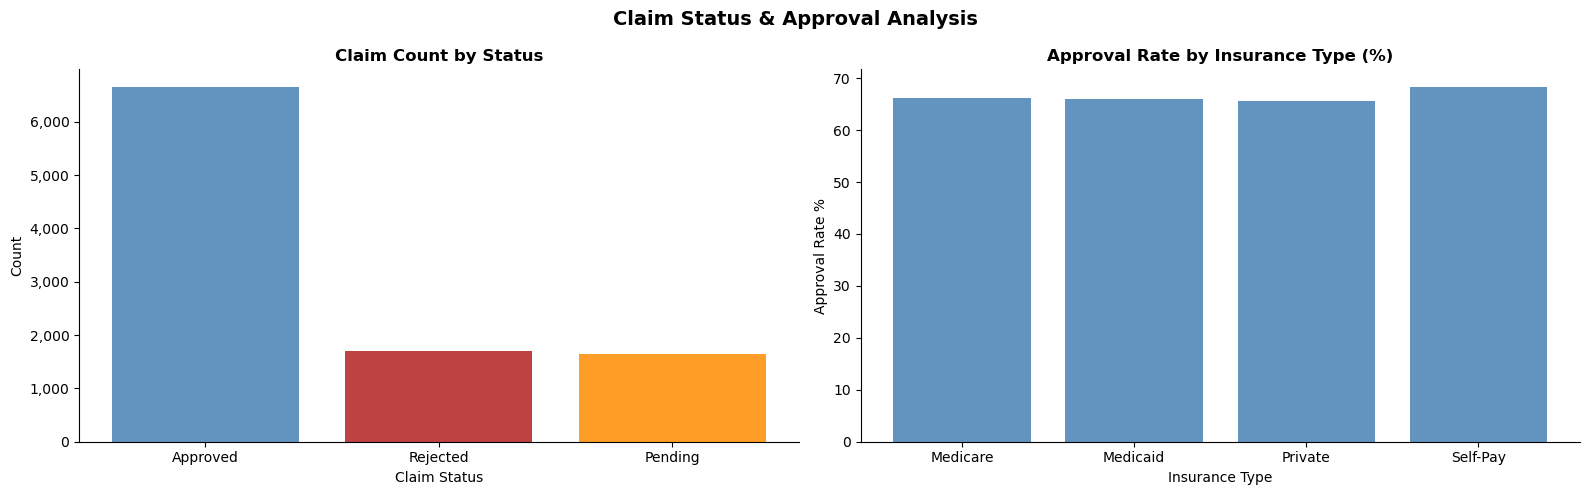

Claim Status:
Claim_Status  claim_count  share_pct  total_claimed  total_approved  avg_claim_amount  avg_approval_pct
    Approved         6649      66.49 165,853,951.57  141,163,565.28         24,944.19             85.15
    Rejected         1702      17.02  43,348,620.36   36,841,151.88         25,469.22             84.78
     Pending         1649      16.49  42,320,230.81   36,086,601.64         25,664.18             85.39

Insurance Type:
Insurance_Type  claim_count  total_claimed  avg_claim_amount  approval_rate_pct  fraud_rate_pct
      Medicare         2594  64,282,506.24         24,781.23              66.15            9.60
      Medicaid         2530  63,669,334.94         25,165.75              66.01           10.79
       Private         2470  63,436,688.14         25,682.87              65.59            9.84
      Self-Pay         2406  60,134,273.42         24,993.46              68.29            9.52


In [3]:
status_kpi = duckdb.query("""
    SELECT
        Claim_Status,
        COUNT(*)                                                              AS claim_count,
        ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(), 2)                        AS share_pct,
        ROUND(SUM(Claim_Amount), 2)                                           AS total_claimed,
        ROUND(SUM(Approved_Amount), 2)                                        AS total_approved,
        ROUND(AVG(Claim_Amount), 2)                                           AS avg_claim_amount,
        ROUND(AVG(Approval_Ratio)*100, 2)                                     AS avg_approval_pct
    FROM master
    GROUP BY Claim_Status
    ORDER BY claim_count DESC
""").df()

insurance_kpi = duckdb.query("""
    SELECT
        Insurance_Type,
        COUNT(*)                                                              AS claim_count,
        ROUND(SUM(Claim_Amount), 2)                                           AS total_claimed,
        ROUND(AVG(Claim_Amount), 2)                                           AS avg_claim_amount,
        ROUND(AVG(Is_Approved)*100, 2)                                        AS approval_rate_pct,
        ROUND(AVG(Is_Fraud)*100, 2)                                           AS fraud_rate_pct
    FROM master
    WHERE Insurance_Type IS NOT NULL
    GROUP BY Insurance_Type
    ORDER BY total_claimed DESC
""").df()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(status_kpi['Claim_Status'], status_kpi['claim_count'],
            color=['steelblue', 'firebrick', 'darkorange'], alpha=0.85)
axes[0].set_title('Claim Count by Status', fontweight='bold')
axes[0].set_xlabel('Claim Status')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))

axes[1].bar(insurance_kpi['Insurance_Type'], insurance_kpi['approval_rate_pct'],
            color='steelblue', alpha=0.85)
axes[1].set_title('Approval Rate by Insurance Type (%)', fontweight='bold')
axes[1].set_xlabel('Insurance Type')
axes[1].set_ylabel('Approval Rate %')

plt.suptitle('Claim Status & Approval Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DASHBOARD_DIR, 'claim_status_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Claim Status:')
print(status_kpi.to_string(index=False))
print('\nInsurance Type:')
print(insurance_kpi.to_string(index=False))

## KPI 3: Fraud Analysis

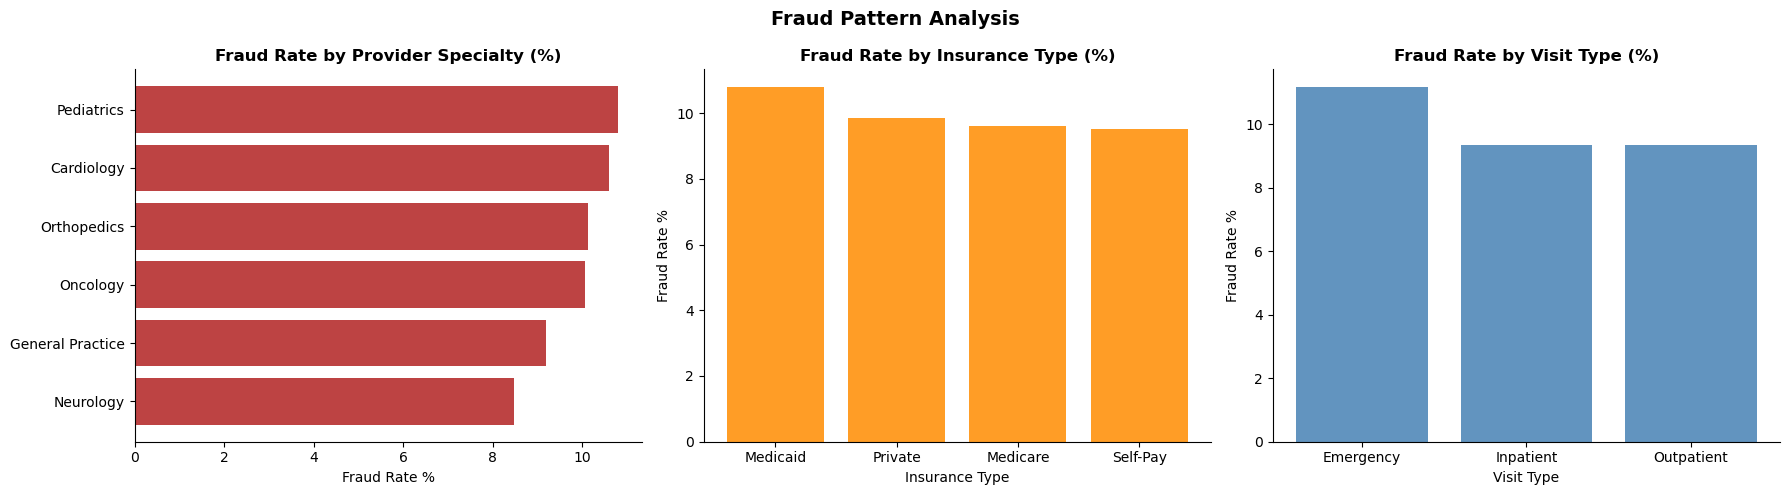

Fraud by Specialty:
Provider_Specialty  total_claims  fraud_claims  fraud_rate_pct  fraud_amount
        Pediatrics          1678        181.00           10.79  4,132,261.42
        Cardiology          1974        209.00           10.59  5,447,578.67
       Orthopedics          1599        162.00           10.13  4,183,450.58
          Oncology          1670        168.00           10.06  3,878,226.47
  General Practice          1794        165.00            9.20  4,093,818.32
         Neurology          1285        109.00            8.48  2,698,026.36

Fraud by Insurance Type:
Insurance_Type  total_claims  fraud_claims  fraud_rate_pct  fraud_amount
      Medicaid          2530        273.00           10.79  6,532,343.46
       Private          2470        243.00            9.84  6,318,441.01
      Medicare          2594        249.00            9.60  5,871,160.97
      Self-Pay          2406        229.00            9.52  5,711,416.38

Fraud by Visit Type:
Visit_Type  total_claims  fr

In [10]:
fraud_specialty = duckdb.query("""
    SELECT
        Provider_Specialty,
        COUNT(*)                                                              AS total_claims,
        SUM(Is_Fraud)                                                         AS fraud_claims,
        ROUND(AVG(Is_Fraud)*100, 2)                                           AS fraud_rate_pct,
        ROUND(SUM(CASE WHEN Is_Fraud=1 THEN Claim_Amount ELSE 0 END), 2)     AS fraud_amount
    FROM master
    WHERE Provider_Specialty IS NOT NULL
    GROUP BY Provider_Specialty
    ORDER BY fraud_rate_pct DESC
""").df()

fraud_insurance = duckdb.query("""
    SELECT
        Insurance_Type,
        COUNT(*)                                                              AS total_claims,
        SUM(Is_Fraud)                                                         AS fraud_claims,
        ROUND(AVG(Is_Fraud)*100, 2)                                           AS fraud_rate_pct,
        ROUND(SUM(CASE WHEN Is_Fraud=1 THEN Claim_Amount ELSE 0 END), 2)     AS fraud_amount
    FROM master
    WHERE Insurance_Type IS NOT NULL
    GROUP BY Insurance_Type
    ORDER BY fraud_rate_pct DESC
""").df()

fraud_visit = duckdb.query("""
    SELECT
        Visit_Type,
        COUNT(*)                                                              AS total_claims,
        SUM(Is_Fraud)                                                         AS fraud_claims,
        ROUND(AVG(Is_Fraud)*100, 2)                                           AS fraud_rate_pct,
        ROUND(AVG(CASE WHEN Is_Fraud=1 THEN Claim_Amount END), 2)            AS avg_fraud_claim_amount
    FROM master
    GROUP BY Visit_Type
    ORDER BY fraud_rate_pct DESC
""").df()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].barh(fraud_specialty['Provider_Specialty'], fraud_specialty['fraud_rate_pct'],
             color='firebrick', alpha=0.85)
axes[0].set_title('Fraud Rate by Provider Specialty (%)', fontweight='bold')
axes[0].set_xlabel('Fraud Rate %')
axes[0].invert_yaxis()

axes[1].bar(fraud_insurance['Insurance_Type'], fraud_insurance['fraud_rate_pct'],
            color='darkorange', alpha=0.85)
axes[1].set_title('Fraud Rate by Insurance Type (%)', fontweight='bold')
axes[1].set_xlabel('Insurance Type')
axes[1].set_ylabel('Fraud Rate %')

axes[2].bar(fraud_visit['Visit_Type'], fraud_visit['fraud_rate_pct'],
            color='steelblue', alpha=0.85)
axes[2].set_title('Fraud Rate by Visit Type (%)', fontweight='bold')
axes[2].set_xlabel('Visit Type')
axes[2].set_ylabel('Fraud Rate %')

plt.suptitle('Fraud Pattern Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DASHBOARD_DIR, 'fraud_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Fraud by Specialty:')
print(fraud_specialty.to_string(index=False))
print('\nFraud by Insurance Type:')
print(fraud_insurance.to_string(index=False))
print('\nFraud by Visit Type:')
print(fraud_visit.to_string(index=False))

## KPI 4: Provider Performance Analysis

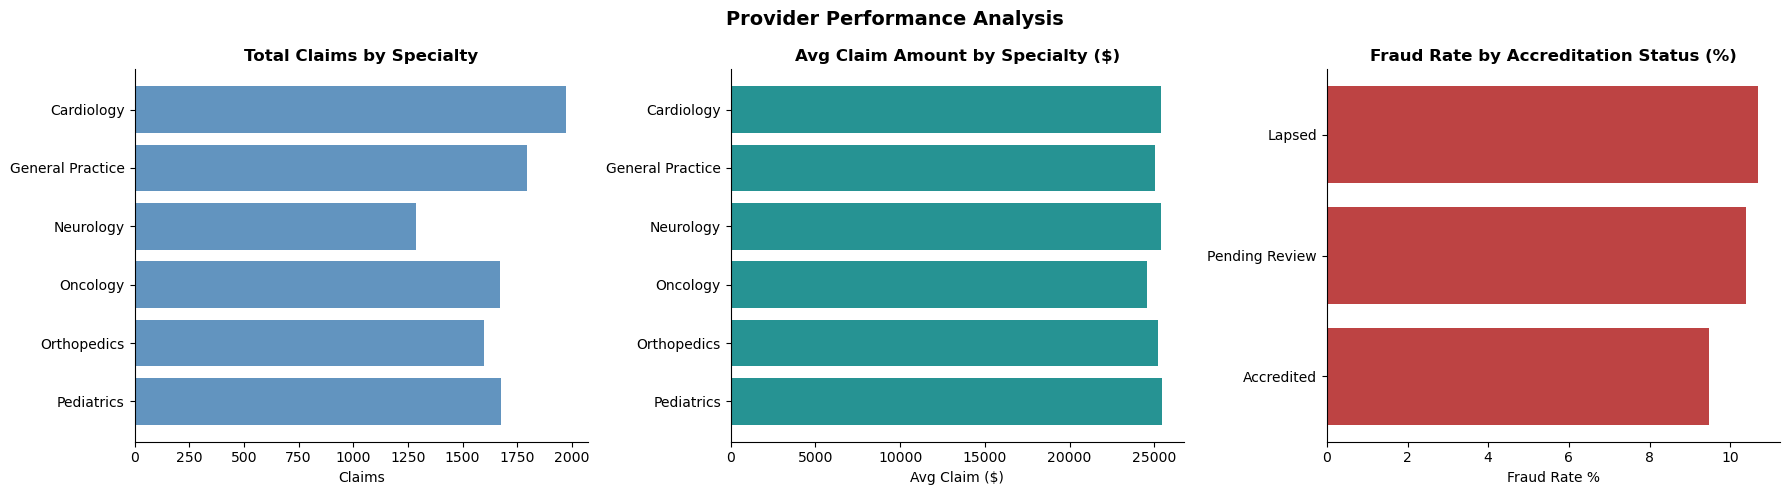

High Risk vs Normal Providers:
 Provider_Is_High_Risk  total_claims  avg_claim_amount  approval_rate_pct  fraud_rate_pct  avg_days_to_payment
                     0          7819         25,314.26              66.54           10.13                60.99
                     1          2181         24,571.59              66.30            9.26                59.85

Accreditation Status Analysis:
Accreditation_Status  total_claims  avg_claim_amount  approval_rate_pct  fraud_rate_pct
              Lapsed          2253         25,045.16              67.02           10.70
      Pending Review          2009         24,631.78              67.15           10.40
          Accredited          5738         25,376.58              66.05            9.48


In [5]:
provider_kpi = duckdb.query("""
    SELECT
        Provider_Specialty,
        Hospital_Type,
        COUNT(*)                                                              AS total_claims,
        ROUND(SUM(Claim_Amount), 2)                                           AS total_claimed,
        ROUND(AVG(Claim_Amount), 2)                                           AS avg_claim_amount,
        ROUND(AVG(Is_Approved)*100, 2)                                        AS approval_rate_pct,
        ROUND(AVG(Is_Fraud)*100, 2)                                           AS fraud_rate_pct,
        ROUND(AVG(Provider_Rating), 2)                                        AS avg_provider_rating
    FROM master
    WHERE Provider_Specialty IS NOT NULL
    GROUP BY Provider_Specialty, Hospital_Type
    ORDER BY total_claimed DESC
""").df()

high_risk = duckdb.query("""
    SELECT
        Provider_Is_High_Risk,
        COUNT(*)                                                              AS total_claims,
        ROUND(AVG(Claim_Amount), 2)                                           AS avg_claim_amount,
        ROUND(AVG(Is_Approved)*100, 2)                                        AS approval_rate_pct,
        ROUND(AVG(Is_Fraud)*100, 2)                                           AS fraud_rate_pct,
        ROUND(AVG(Days_to_Payment), 2)                                        AS avg_days_to_payment
    FROM master
    WHERE Provider_Is_High_Risk IS NOT NULL
    GROUP BY Provider_Is_High_Risk
    ORDER BY Provider_Is_High_Risk
""").df()

accreditation_kpi = duckdb.query("""
    SELECT
        Accreditation_Status,
        COUNT(*)                                                              AS total_claims,
        ROUND(AVG(Claim_Amount), 2)                                           AS avg_claim_amount,
        ROUND(AVG(Is_Approved)*100, 2)                                        AS approval_rate_pct,
        ROUND(AVG(Is_Fraud)*100, 2)                                           AS fraud_rate_pct
    FROM master
    WHERE Accreditation_Status IS NOT NULL
    GROUP BY Accreditation_Status
    ORDER BY fraud_rate_pct DESC
""").df()

specialty_summary = provider_kpi.groupby('Provider_Specialty').agg(
    total_claims=('total_claims','sum'),
    avg_claim=('avg_claim_amount','mean'),
    approval_rate=('approval_rate_pct','mean'),
    fraud_rate=('fraud_rate_pct','mean')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].barh(specialty_summary['Provider_Specialty'],
             specialty_summary['total_claims'], color='steelblue', alpha=0.85)
axes[0].set_title('Total Claims by Specialty', fontweight='bold')
axes[0].set_xlabel('Claims')
axes[0].invert_yaxis()

axes[1].barh(specialty_summary['Provider_Specialty'],
             specialty_summary['avg_claim'], color='teal', alpha=0.85)
axes[1].set_title('Avg Claim Amount by Specialty ($)', fontweight='bold')
axes[1].set_xlabel('Avg Claim ($)')
axes[1].invert_yaxis()

axes[2].barh(accreditation_kpi['Accreditation_Status'],
             accreditation_kpi['fraud_rate_pct'], color='firebrick', alpha=0.85)
axes[2].set_title('Fraud Rate by Accreditation Status (%)', fontweight='bold')
axes[2].set_xlabel('Fraud Rate %')
axes[2].invert_yaxis()

plt.suptitle('Provider Performance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DASHBOARD_DIR, 'provider_performance.png'), dpi=150, bbox_inches='tight')
plt.show()

print('High Risk vs Normal Providers:')
print(high_risk.to_string(index=False))
print('\nAccreditation Status Analysis:')
print(accreditation_kpi.to_string(index=False))

## KPI 5: Payment Performance Analysis

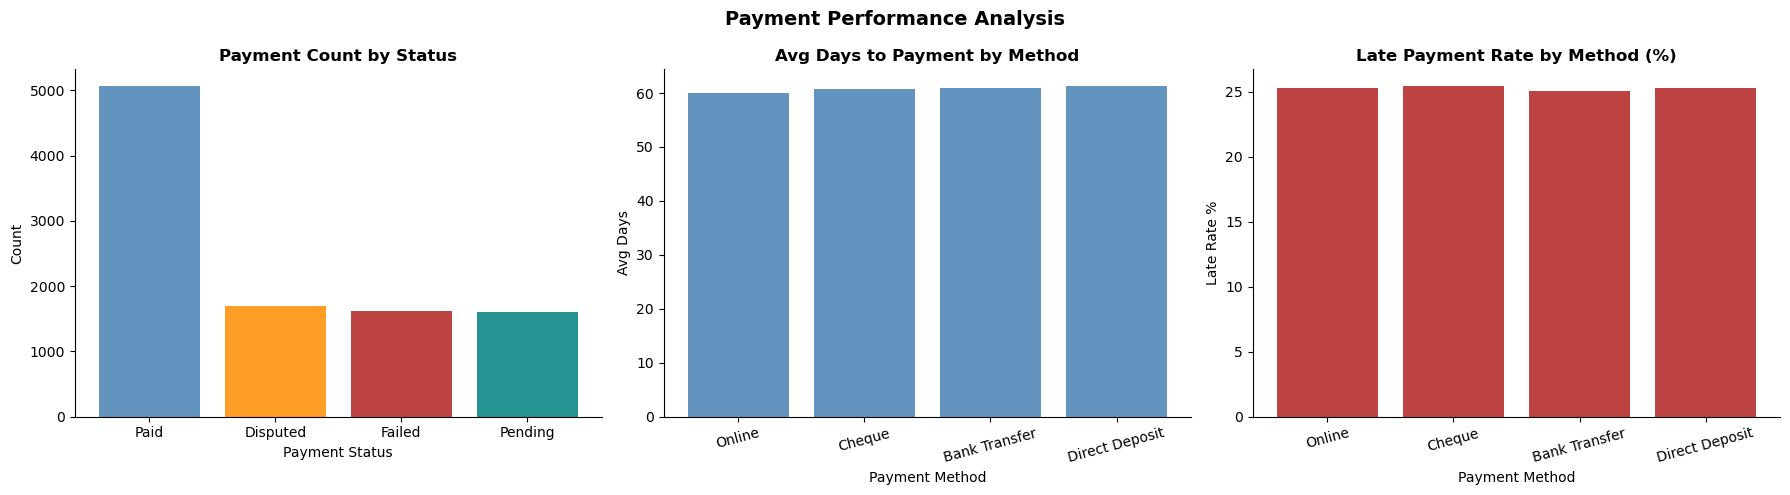

Payment Status:
Payment_Status  payment_count  share_pct   total_amount  avg_amount  avg_days_to_payment
          Paid           5071      50.71 105,008,077.06   20,707.57                61.25
      Disputed           1695      16.95  35,715,412.17   21,071.04                60.30
        Failed           1625      16.25  34,150,551.47   21,015.72                60.78
       Pending           1609      16.09  33,862,980.27   21,045.98                59.56

Payment Method Performance:
Payment_Method  payment_count  avg_days_to_payment  late_payment_rate_pct  total_amount
        Online           2529                60.09                  25.31 52,232,502.08
        Cheque           2478                60.67                  25.46 51,778,929.23
 Bank Transfer           2486                60.86                  25.06 52,561,760.89
Direct Deposit           2507                61.34                  25.33 52,163,828.77


In [6]:
payment_kpi = duckdb.query("""
    SELECT
        Payment_Status,
        COUNT(*)                                                              AS payment_count,
        ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(), 2)                        AS share_pct,
        ROUND(SUM(Payment_Amount), 2)                                         AS total_amount,
        ROUND(AVG(Payment_Amount), 2)                                         AS avg_amount,
        ROUND(AVG(Days_to_Payment), 2)                                        AS avg_days_to_payment
    FROM master
    WHERE Payment_Status IS NOT NULL
    GROUP BY Payment_Status
    ORDER BY payment_count DESC
""").df()

payment_method_kpi = duckdb.query("""
    SELECT
        Payment_Method,
        COUNT(*)                                                              AS payment_count,
        ROUND(AVG(Days_to_Payment), 2)                                        AS avg_days_to_payment,
        ROUND(AVG(Late_Payment_Flag)*100, 2)                                  AS late_payment_rate_pct,
        ROUND(SUM(Payment_Amount), 2)                                         AS total_amount
    FROM master
    WHERE Payment_Method IS NOT NULL
    GROUP BY Payment_Method
    ORDER BY avg_days_to_payment ASC
""").df()

payment_speed_kpi = duckdb.query("""
    SELECT
        Payment_Speed,
        COUNT(*)                                                              AS payment_count,
        ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(), 2)                        AS share_pct,
        ROUND(AVG(Payment_Amount), 2)                                         AS avg_amount
    FROM master
    WHERE Payment_Speed IS NOT NULL
    GROUP BY Payment_Speed
    ORDER BY payment_count DESC
""").df()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(payment_kpi['Payment_Status'], payment_kpi['payment_count'],
            color=['steelblue','darkorange','firebrick','teal'], alpha=0.85)
axes[0].set_title('Payment Count by Status', fontweight='bold')
axes[0].set_xlabel('Payment Status')
axes[0].set_ylabel('Count')

axes[1].bar(payment_method_kpi['Payment_Method'],
            payment_method_kpi['avg_days_to_payment'],
            color='steelblue', alpha=0.85)
axes[1].set_title('Avg Days to Payment by Method', fontweight='bold')
axes[1].set_xlabel('Payment Method')
axes[1].set_ylabel('Avg Days')
axes[1].tick_params(axis='x', rotation=15)

axes[2].bar(payment_method_kpi['Payment_Method'],
            payment_method_kpi['late_payment_rate_pct'],
            color='firebrick', alpha=0.85)
axes[2].set_title('Late Payment Rate by Method (%)', fontweight='bold')
axes[2].set_xlabel('Payment Method')
axes[2].set_ylabel('Late Rate %')
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('Payment Performance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DASHBOARD_DIR, 'payment_performance.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Payment Status:')
print(payment_kpi.to_string(index=False))
print('\nPayment Method Performance:')
print(payment_method_kpi.to_string(index=False))

## KPI 6: Patient Demographics Analysis

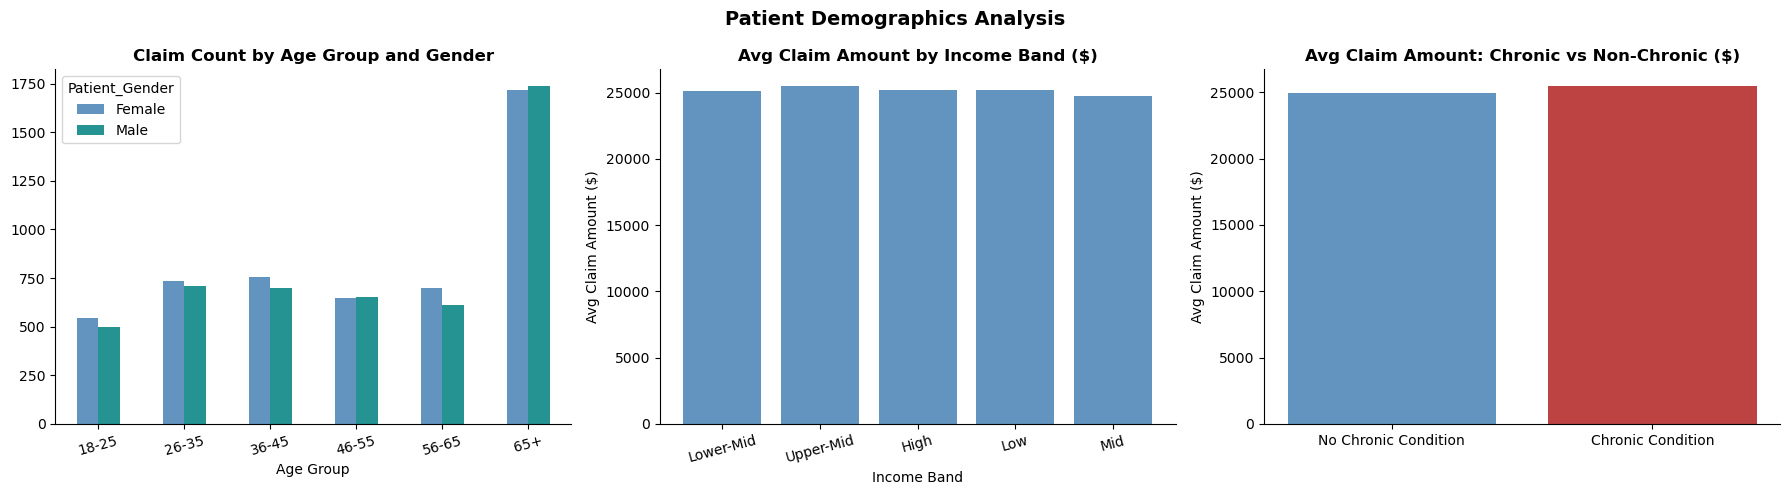

Chronic Condition Impact:
 Chronic_Condition_Flag  claim_count  avg_claim_amount  avg_length_of_stay  approval_rate_pct  fraud_rate_pct
                      0         6667         24,993.46               14.86              66.45            9.99
                      1         3333         25,469.97               15.19              66.58            9.84

Income Band Analysis:
Annual_Income_Band  claim_count  avg_claim_amount  approval_rate_pct  fraud_rate_pct
         Lower-Mid         2086         25,124.16              66.97           11.07
         Upper-Mid         2071         25,477.09              65.48           10.77
              High         2003         25,188.88              67.50            8.84
               Low         1998         25,215.58              65.52            9.81
               Mid         1842         24,710.48              67.05            9.07


In [7]:
age_kpi = duckdb.query("""
    SELECT
        Age_Group,
        Patient_Gender,
        COUNT(*)                                                              AS claim_count,
        ROUND(SUM(Claim_Amount), 2)                                           AS total_claimed,
        ROUND(AVG(Claim_Amount), 2)                                           AS avg_claim_amount,
        ROUND(AVG(Is_Approved)*100, 2)                                        AS approval_rate_pct
    FROM master
    WHERE Age_Group IS NOT NULL
    AND Patient_Gender IS NOT NULL
    GROUP BY Age_Group, Patient_Gender
    ORDER BY Age_Group, Patient_Gender
""").df()

chronic_kpi = duckdb.query("""
    SELECT
        Chronic_Condition_Flag,
        COUNT(*)                                                              AS claim_count,
        ROUND(AVG(Claim_Amount), 2)                                           AS avg_claim_amount,
        ROUND(AVG(Length_of_Stay), 2)                                         AS avg_length_of_stay,
        ROUND(AVG(Is_Approved)*100, 2)                                        AS approval_rate_pct,
        ROUND(AVG(Is_Fraud)*100, 2)                                           AS fraud_rate_pct
    FROM master
    GROUP BY Chronic_Condition_Flag
    ORDER BY Chronic_Condition_Flag
""").df()

income_kpi = duckdb.query("""
    SELECT
        Annual_Income_Band,
        COUNT(*)                                                              AS claim_count,
        ROUND(AVG(Claim_Amount), 2)                                           AS avg_claim_amount,
        ROUND(AVG(Is_Approved)*100, 2)                                        AS approval_rate_pct,
        ROUND(AVG(Is_Fraud)*100, 2)                                           AS fraud_rate_pct
    FROM master
    WHERE Annual_Income_Band IS NOT NULL
    GROUP BY Annual_Income_Band
    ORDER BY claim_count DESC
""").df()

age_pivot = age_kpi.pivot(index='Age_Group', columns='Patient_Gender', values='claim_count').fillna(0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

age_pivot.plot(kind='bar', ax=axes[0], color=['steelblue','teal'], alpha=0.85)
axes[0].set_title('Claim Count by Age Group and Gender', fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(income_kpi['Annual_Income_Band'], income_kpi['avg_claim_amount'],
            color='steelblue', alpha=0.85)
axes[1].set_title('Avg Claim Amount by Income Band ($)', fontweight='bold')
axes[1].set_xlabel('Income Band')
axes[1].set_ylabel('Avg Claim Amount ($)')
axes[1].tick_params(axis='x', rotation=15)

chronic_labels = ['No Chronic Condition', 'Chronic Condition']
axes[2].bar(chronic_labels,
            chronic_kpi['avg_claim_amount'],
            color=['steelblue','firebrick'], alpha=0.85)
axes[2].set_title('Avg Claim Amount: Chronic vs Non-Chronic ($)', fontweight='bold')
axes[2].set_ylabel('Avg Claim Amount ($)')

plt.suptitle('Patient Demographics Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DASHBOARD_DIR, 'patient_demographics.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Chronic Condition Impact:')
print(chronic_kpi.to_string(index=False))
print('\nIncome Band Analysis:')
print(income_kpi.to_string(index=False))

## KPI 7: Diagnosis & Visit Type Analysis

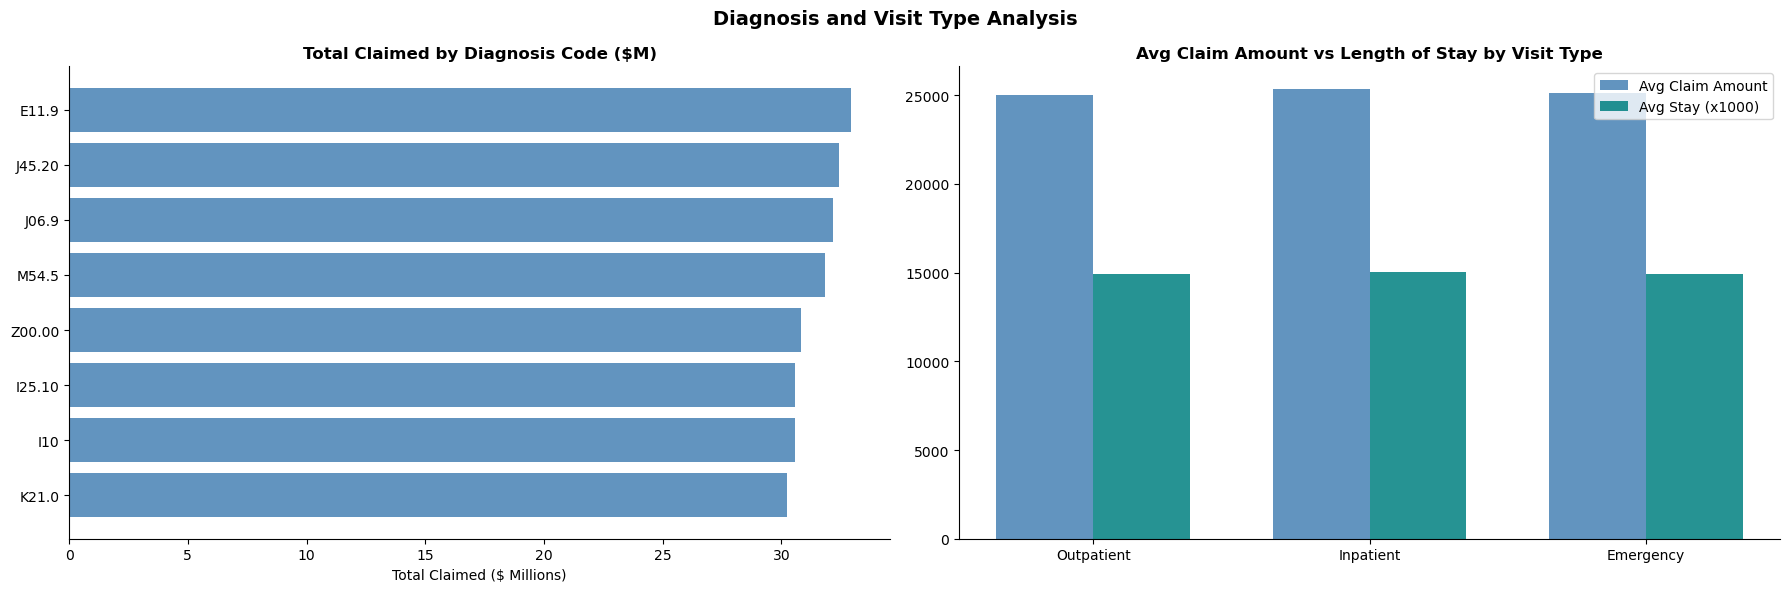

Visit Type Summary:
Visit_Type  claim_count  total_claimed  avg_claim_amount  avg_length_of_stay  approval_rate_pct  fraud_rate_pct
Outpatient         3431  85,730,398.28         24,987.00               14.95              66.34            9.33
 Inpatient         3283  83,259,414.65         25,360.77               15.01              66.71            9.35
 Emergency         3286  82,532,989.81         25,116.55               14.95              66.43           11.17

Diagnosis Code Summary:
Diagnosis_Code  claim_count  total_claimed  avg_claim_amount  approval_rate_pct  fraud_rate_pct  avg_length_of_stay
         E11.9         1287  32,929,064.94         25,585.91              66.51            9.87               14.96
        J45.20         1273  32,411,502.38         25,460.72              65.20            9.98               14.83
         J06.9         1257  32,167,580.94         25,590.76              66.51           10.98               14.36
         M54.5         1243  31,832,440.86 

In [8]:
diagnosis_kpi = duckdb.query("""
    SELECT
        Diagnosis_Code,
        COUNT(*)                                                              AS claim_count,
        ROUND(SUM(Claim_Amount), 2)                                           AS total_claimed,
        ROUND(AVG(Claim_Amount), 2)                                           AS avg_claim_amount,
        ROUND(AVG(Is_Approved)*100, 2)                                        AS approval_rate_pct,
        ROUND(AVG(Is_Fraud)*100, 2)                                           AS fraud_rate_pct,
        ROUND(AVG(Length_of_Stay), 2)                                         AS avg_length_of_stay
    FROM master
    GROUP BY Diagnosis_Code
    ORDER BY total_claimed DESC
""").df()

visit_kpi = duckdb.query("""
    SELECT
        Visit_Type,
        COUNT(*)                                                              AS claim_count,
        ROUND(SUM(Claim_Amount), 2)                                           AS total_claimed,
        ROUND(AVG(Claim_Amount), 2)                                           AS avg_claim_amount,
        ROUND(AVG(Length_of_Stay), 2)                                         AS avg_length_of_stay,
        ROUND(AVG(Is_Approved)*100, 2)                                        AS approval_rate_pct,
        ROUND(AVG(Is_Fraud)*100, 2)                                           AS fraud_rate_pct
    FROM master
    GROUP BY Visit_Type
    ORDER BY total_claimed DESC
""").df()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].barh(diagnosis_kpi['Diagnosis_Code'],
             diagnosis_kpi['total_claimed']/1e6, color='steelblue', alpha=0.85)
axes[0].set_title('Total Claimed by Diagnosis Code ($M)', fontweight='bold')
axes[0].set_xlabel('Total Claimed ($ Millions)')
axes[0].invert_yaxis()

x = range(len(visit_kpi))
width = 0.35
axes[1].bar([i - width/2 for i in x], visit_kpi['avg_claim_amount'],
            width=width, label='Avg Claim Amount', color='steelblue', alpha=0.85)
axes[1].bar([i + width/2 for i in x], visit_kpi['avg_length_of_stay']*1000,
            width=width, label='Avg Stay (x1000)', color='teal', alpha=0.85)
axes[1].set_title('Avg Claim Amount vs Length of Stay by Visit Type', fontweight='bold')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(visit_kpi['Visit_Type'])
axes[1].legend()

plt.suptitle('Diagnosis and Visit Type Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DASHBOARD_DIR, 'diagnosis_visit_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Visit Type Summary:')
print(visit_kpi.to_string(index=False))
print('\nDiagnosis Code Summary:')
print(diagnosis_kpi.to_string(index=False))

## KPI 8: Yearly Claims Trend

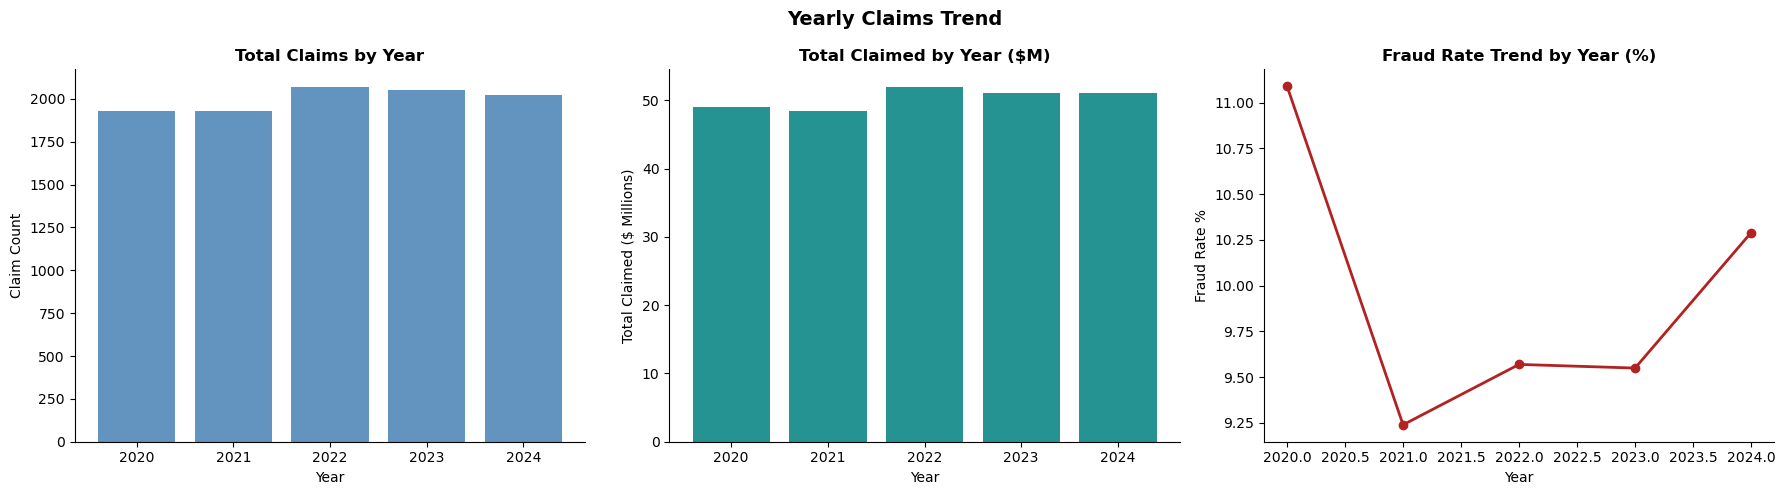

 Claim_Year  total_claims  total_claimed  avg_claim_amount  approval_rate_pct  fraud_rate_pct  fraud_count
       2020          1930  48,961,260.57         25,368.53              68.13           11.09       214.00
       2021          1927  48,434,813.60         25,134.83              66.32            9.24       178.00
       2022          2069  51,944,560.44         25,106.12              66.75            9.57       198.00
       2023          2052  51,084,791.24         24,895.12              65.50            9.55       196.00
       2024          2022  51,097,376.89         25,270.71              65.83           10.29       208.00


In [9]:
yearly_kpi = duckdb.query("""
    SELECT
        Claim_Year,
        COUNT(*)                                                              AS total_claims,
        ROUND(SUM(Claim_Amount), 2)                                           AS total_claimed,
        ROUND(AVG(Claim_Amount), 2)                                           AS avg_claim_amount,
        ROUND(AVG(Is_Approved)*100, 2)                                        AS approval_rate_pct,
        ROUND(AVG(Is_Fraud)*100, 2)                                           AS fraud_rate_pct,
        SUM(Is_Fraud)                                                         AS fraud_count
    FROM master
    WHERE Claim_Year IS NOT NULL
    GROUP BY Claim_Year
    ORDER BY Claim_Year
""").df()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(yearly_kpi['Claim_Year'], yearly_kpi['total_claims'],
            color='steelblue', alpha=0.85)
axes[0].set_title('Total Claims by Year', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Claim Count')

axes[1].bar(yearly_kpi['Claim_Year'], yearly_kpi['total_claimed']/1e6,
            color='teal', alpha=0.85)
axes[1].set_title('Total Claimed by Year ($M)', fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Total Claimed ($ Millions)')

axes[2].plot(yearly_kpi['Claim_Year'], yearly_kpi['fraud_rate_pct'],
             marker='o', color='firebrick', linewidth=2)
axes[2].set_title('Fraud Rate Trend by Year (%)', fontweight='bold')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Fraud Rate %')

plt.suptitle('Yearly Claims Trend', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DASHBOARD_DIR, 'yearly_trends.png'), dpi=150, bbox_inches='tight')
plt.show()

print(yearly_kpi.to_string(index=False))

## Key Business Insights

---

### Finding 01 — Approval Rate is Consistent Across All Insurance Types at Approximately 65%

The claim status analysis shows approximately 6,500 approved claims, 1,750 rejected,
and 1,600 pending out of 10,000 total claims. The approval rate across all four
insurance types — Medicare, Medicaid, Private, and Self-Pay — sits at virtually
identical levels between 65% and 67%. There is no meaningful differentiation between
insurance types in terms of how often claims get approved.

**Recommendation:** The uniform approval rate across insurance types indicates the
approval decision is being driven by claim-level factors — diagnosis, provider,
visit type — rather than insurance type. The 17% rejection rate on a 10,000 claim
portfolio represents significant denied revenue that warrants a detailed rejection
reason analysis as a follow-on engagement.

---

### Finding 02 — Pediatrics and Cardiology Carry the Highest Fraud Rates Among All Specialties

Pediatrics shows the highest fraud rate at approximately 11% followed closely by
Cardiology at approximately 10.5%. Orthopedics and Oncology sit at approximately 10%.
General Practice at approximately 9.5% and Neurology at approximately 8.5% are the
lowest risk specialties. Cardiology also generates the highest total claim count at
approximately 2,000 claims — making the combination of high volume and elevated
fraud rate the single highest priority area for fraud intervention.

**Recommendation:** Pediatrics and Cardiology claims should be subject to enhanced
review protocols. A dedicated audit of the top 50 highest-value Cardiology claims
from high-risk providers would deliver the highest return of any investigative action
given the volume-fraud combination in that specialty.

---

### Finding 03 — Medicaid Carries the Highest Fraud Rate Among Insurance Types

Medicaid shows a fraud rate of approximately 10.7% — the highest of all four
insurance types. Private follows at approximately 10%, Medicare at approximately
9.8%, and Self-Pay at approximately 9.6%. The spread between highest and lowest
is approximately 1 percentage point — fraud is broadly distributed but Medicaid
claims carry a marginally higher risk profile.

**Recommendation:** Medicaid claims warrant a slightly elevated scrutiny threshold
in the automated review pipeline. The additional fraud exposure from Medicaid
relative to other types is manageable with targeted rule-based flagging rather
than wholesale manual review.

---

### Finding 04 — Emergency Visit Claims Carry the Highest Fraud Rate at Approximately 11%

Among the three visit types, Emergency visits show a fraud rate of approximately
11% — materially higher than Inpatient and Outpatient both sitting at approximately
9.3%. Average claim amounts are broadly similar across all three visit types at
approximately $25,000 — meaning Emergency fraud events carry the same financial
impact per claim as other types but occur more frequently.

**Recommendation:** Emergency claim submissions should trigger automatic enhanced
review when combined with any other fraud risk indicator — high-risk provider flag,
Medicaid insurance type, or Pediatrics and Cardiology specialty. The intersection
of Emergency visit type with these elevated-risk dimensions is where the highest
concentration of genuine fraud is most likely to occur.

---

### Finding 05 — All Payment Methods Average 60 Days to Settlement with a 25% Late Rate

All four payment methods — Online, Cheque, Bank Transfer, and Direct Deposit —
average approximately 60 days to payment with no meaningful difference between
them. The late payment rate is approximately 25% uniformly across all methods.
This uniformity confirms the bottleneck is not in the payment method itself but
in an upstream process — most likely the claim review and approval cycle.

**Recommendation:** Switching payment methods will not improve settlement speed.
The 60-day average and 25% late rate point to a process bottleneck in the claim
review and approval workflow. The business should map the end-to-end claim
lifecycle to identify where the delay originates. Targeting a 30-day average
settlement cycle should be a defined operational KPI for the next financial year.

---

### Finding 06 — Fraud Rate Peaked at 11% in 2020, Dropped to 9.2% in 2021, and is Rising Again in 2024

The yearly fraud trend shows fraud rate starting at approximately 11% in 2020,
dropping sharply to 9.2% in 2021 — the lowest point in the five-year dataset —
then gradually rising through 2022 and 2023 at approximately 9.6% before climbing
to approximately 10.3% in 2024. The 2024 rise is the most operationally
concerning data point in the entire dataset.

**Recommendation:** The rising fraud rate in 2024 should be treated as an early
warning signal requiring immediate investigation. The business should analyse
whether the 2024 increase is concentrated in specific specialties, providers,
or claim types. If the trend continues at the same trajectory into 2025 the
fraud rate will approach or exceed the 2020 peak — making 2024 the most important
year for fraud intervention investment.

---

### Finding 07 — Providers with Lapsed Accreditation Carry the Highest Fraud Rate at 11%

Lapsed accreditation status shows the highest fraud rate at approximately 11%,
followed by Pending Review at approximately 10.7%, and fully Accredited providers
at approximately 9.5%. However even Accredited providers generate a 9.5% fraud
rate — indicating the overall fraud problem is not exclusively concentrated in
non-accredited providers and that accreditation status alone is an insufficient
fraud screen.

**Recommendation:** Accreditation status should be used as a fraud risk multiplier
in the automated review system rather than a binary filter. A composite risk score
combining accreditation status, specialty, visit type, and claim amount will produce
significantly better fraud detection outcomes than any single factor in isolation.

---

### Finding 08 — The 65-Plus Age Group Drives the Highest Claim Volume of All Age Segments

The patient demographics analysis shows the 65-plus age group generating the highest
claim count of all six age groups at approximately 1,700 female and 1,650 male
claims. Volume is lowest in the 18-25 group at approximately 500 to 550 claims.
Average claim amounts are consistent across all income bands at approximately
$24,000 to $25,000 — income band does not materially influence claim size in
this portfolio.

**Recommendation:** The 65-plus segment drives disproportionate claim volume
relative to its population size. Healthcare management programmes targeting this
segment — preventive care, chronic disease management, reduced emergency
presentations — would have the highest volume impact of any patient-level
intervention. The consistent average claim amount across income bands indicates
cost management should focus on diagnosis and visit type rather than patient
income segmentation.

In [ ]:
# Export all KPI tables
kpi_overview.to_csv(os.path.join(CLEANED_DATA_DIR, 'kpi_executive_summary.csv'), index=False)
status_kpi.to_csv(os.path.join(CLEANED_DATA_DIR, 'kpi_claim_status.csv'), index=False)
insurance_kpi.to_csv(os.path.join(CLEANED_DATA_DIR, 'kpi_insurance_type.csv'), index=False)
fraud_specialty.to_csv(os.path.join(CLEANED_DATA_DIR, 'kpi_fraud_analysis.csv'), index=False)
provider_kpi.to_csv(os.path.join(CLEANED_DATA_DIR, 'kpi_provider_performance.csv'), index=False)
payment_kpi.to_csv(os.path.join(CLEANED_DATA_DIR, 'kpi_payment_performance.csv'), index=False)
diagnosis_kpi.to_csv(os.path.join(CLEANED_DATA_DIR, 'kpi_diagnosis_analysis.csv'), index=False)
yearly_kpi.to_csv(os.path.join(CLEANED_DATA_DIR, 'kpi_yearly_trends.csv'), index=False)

print('All KPI tables exported to data/cleaned/')
print('  kpi_executive_summary.csv')
print('  kpi_claim_status.csv')
print('  kpi_insurance_type.csv')
print('  kpi_fraud_analysis.csv')
print('  kpi_provider_performance.csv')
print('  kpi_payment_performance.csv')
print('  kpi_diagnosis_analysis.csv')
print('  kpi_yearly_trends.csv')